In [1]:
# 1) Install Kaggle in Colab and upload kaggle.json
!pip install -q kaggle

from google.colab import files
# Run this cell and upload the kaggle.json you downloaded from your Kaggle account
uploaded = files.upload()


Saving kaggle.json to kaggle.json


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
# example - replace with the exact dataset slug if needed
!kaggle datasets download -d moazeldsokyx/plantvillage -q
!unzip -q plantvillage.zip -d /content/plantvillage


Dataset URL: https://www.kaggle.com/datasets/moazeldsokyx/plantvillage
License(s): CC0-1.0


In [4]:
import os
from pathlib import Path

base = Path('/content/plantvillage')  # or where you unzipped
for plant in sorted(base.iterdir())[:10]:
    if plant.is_dir():
        print(plant.name, len(list(plant.glob('*'))))


dataset 3


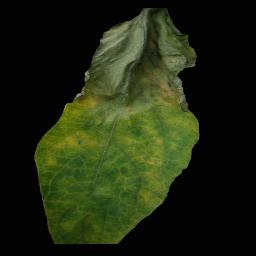

In [5]:
from IPython.display import Image, display
display(Image(str(list(base.glob('**/*.jpg'))[0])))


In [6]:
from pathlib import Path
import os

base = Path('/content/plantvillage')  # change if your unzip path is different
# Find class folders (assuming structure: base/<class_name>/*.jpg)
classes = [p for p in sorted(base.iterdir()) if p.is_dir()]
print(f"Found {len(classes)} class folders (showing first 20):")
for p in classes[:20]:
    count = len(list(p.glob('*.*')))
    print(p.name, "-", count, "images")


Found 1 class folders (showing first 20):
dataset - 0 images


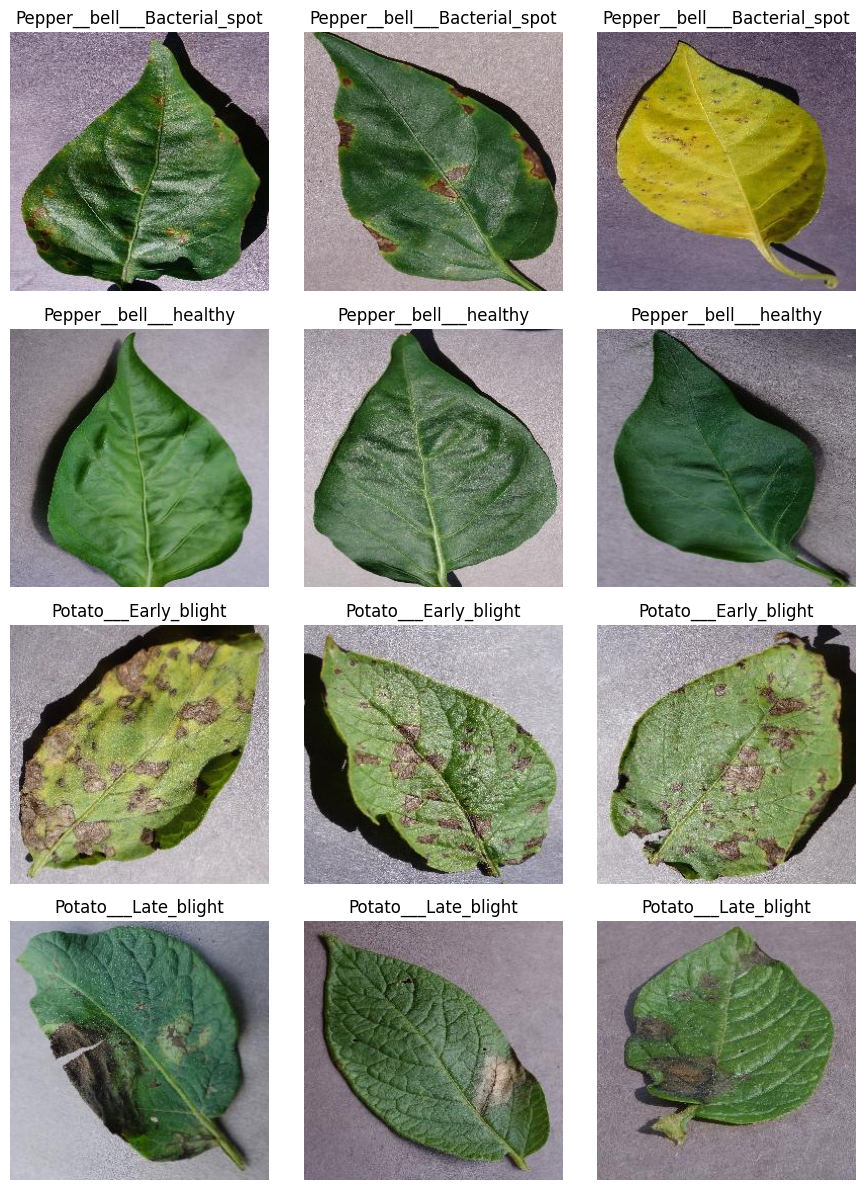

In [12]:
import matplotlib.pyplot as plt
import random
from PIL import Image
from pathlib import Path

train_dir = Path('/content/plantvillage/dataset/train')
classes = [p for p in sorted(train_dir.iterdir()) if p.is_dir()]

def show_samples(base_path, classes, samples_per_class=3):
    plt.figure(figsize=(samples_per_class*3, len(classes[:4])*3))
    i = 1
    for cls in classes[:4]:  # show first 4 classes
        imgs = list(cls.glob('*.*'))
        random.shuffle(imgs)
        for s in range(min(samples_per_class, len(imgs))):
            img = Image.open(imgs[s]).convert('RGB')
            plt.subplot(4, samples_per_class, i)
            plt.imshow(img)
            plt.title(cls.name)
            plt.axis('off')
            i += 1
    plt.tight_layout()

show_samples(train_dir, classes, samples_per_class=3)


In [13]:
from PIL import Image

bad_files = []
for cls in classes:
    for img_path in cls.glob('*.*'):
        try:
            im = Image.open(img_path)
            im.verify()
        except:
            bad_files.append(str(img_path))

len(bad_files), bad_files[:10]


(0, [])

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_dir = '/content/plantvillage/dataset/train'
val_dir   = '/content/plantvillage/dataset/validation'
test_dir  = '/content/plantvillage/dataset/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)

test_gen = val_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1, class_mode='categorical', shuffle=False
)


Found 16504 images belonging to 15 classes.
Found 2070 images belonging to 15 classes.
Found 2064 images belonging to 15 classes.


In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                         include_top=False, weights='imagenet')
base_model.trainable = False  # freeze base model

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy',
                             save_best_only=True, mode='max')
early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[checkpoint, early]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5749 - loss: 1.3692

516/516 ━━━━━━━━━━━━━━━━━━━━ 662s 1s/step - accuracy: 0.5752 - loss: 1.3684 - val_accuracy: 0.8271 - val_loss: 0.5375
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8287 - loss: 0.5264

516/516 ━━━━━━━━━━━━━━━━━━━━ 658s 1s/step - accuracy: 0.8287 - loss: 0.5263 - val_accuracy: 0.8551 - val_loss: 0.4353
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8517 - loss: 0.4433

516/516 ━━━━━━━━━━━━━━━━━━━━ 601s 1s/step - accuracy: 0.8517 - loss: 0.4433 - val_accuracy: 0.8754 - val_loss: 0.3855
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 602s 1s/step - accuracy: 0.8602 - loss: 0.4246 - val_accuracy: 0.8667 - val_loss: 0.3966
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8700 - loss: 0.3873

516/516 ━━━━━━━━━━━━━━━━━━━━ 595s 1s/step - accuracy: 0.8700 - loss: 0.3873 - val_accuracy: 0.8807 - val_loss: 0.3682
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 605s 1s/step - accuracy: 0.8729 - loss: 0.3828 - val_accuracy: 0.8715 - val_loss: 0.3759
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 609s 1s/step - accuracy: 0.8792 - loss: 0.3657 - val_accuracy: 0.8729 - val_loss: 0.3782
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8790 - loss: 0.3694

516/516 ━━━━━━━━━━━━━━━━━━━━ 624s 1s/step - accuracy: 0.8790 - loss: 0.3694 - val_accuracy: 0.8841 - val_loss: 0.3509
Epoch 9/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8860 - loss: 0.3437

516/516 ━━━━━━━━━━━━━━━━━━━━ 632s 1s/step - accuracy: 0.8860 - loss: 0.3437 - val_accuracy: 0.8870 - val_loss: 0.3382
Epoch 10/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8812 - loss: 0.3506

516/516 ━━━━━━━━━━━━━━━━━━━━ 629s 1s/step - accuracy: 0.8812 - loss: 0.3506 - val_accuracy: 0.8908 - val_loss: 0.3362


2064/2064 ━━━━━━━━━━━━━━━━━━━━ 71s 34ms/step - accuracy: 0.9025 - loss: 0.2708
Test Accuracy: 0.8895, Test Loss: 0.3251
2064/2064 ━━━━━━━━━━━━━━━━━━━━ 65s 31ms/step
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.92      0.94       100
                     Pepper__bell___healthy       0.94      0.99      0.96       148
                      Potato___Early_blight       0.98      1.00      0.99       100
                       Potato___Late_blight       0.96      0.76      0.85       100
                           Potato___healthy       0.93      0.87      0.90        15
                      Tomato_Bacterial_spot       0.90      0.92      0.91       213
                        Tomato_Early_blight       0.94      0.59      0.72       100
                         Tomato_Late_blight       0.72      0.96      0.82       191
                           Tomato_Leaf_Mold       0.76      0.84     

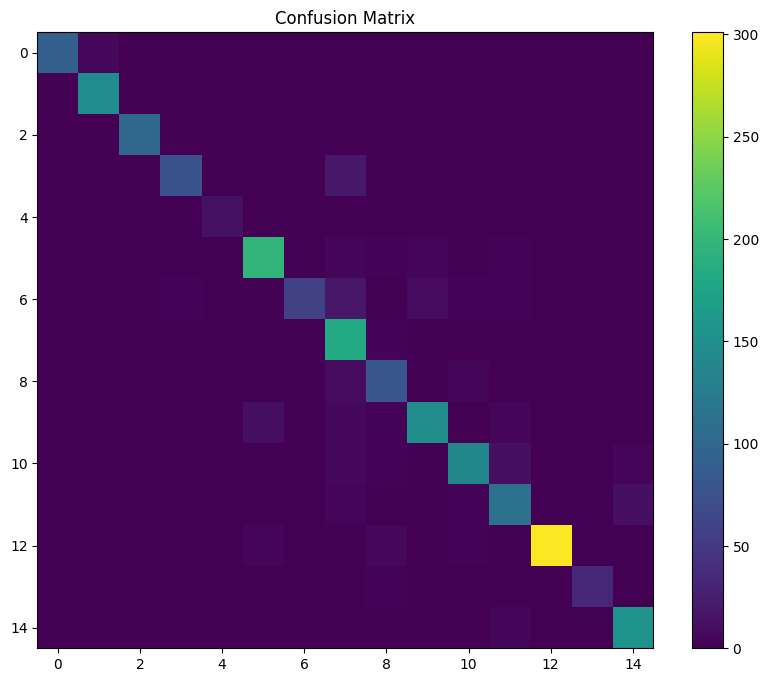

In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_gen, steps=len(test_gen))
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Predictions
preds = model.predict(test_gen, steps=len(test_gen))
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

# Classification Report
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.show()


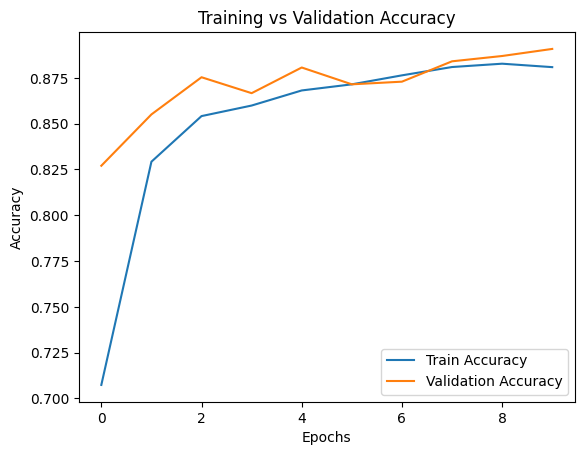

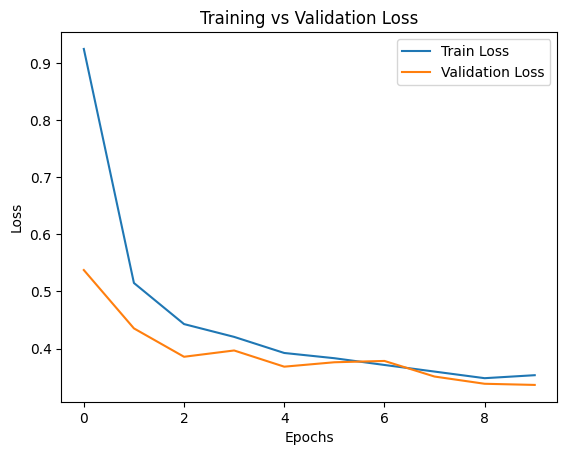

In [18]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


In [19]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

uploaded = files.upload()

for img_name in uploaded.keys():
    img = image.load_img(img_name, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    inv_map = {v: k for k, v in train_gen.class_indices.items()}

    print("Predicted Disease:", inv_map[class_idx])


Saving 1.jpg to 1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step
Predicted Disease: Tomato_Septoria_leaf_spot


In [20]:
model.save("plant_disease_model.keras")  # modern format
model.save("plant_disease_model.h5")     # legacy format (still okay)


In [24]:
from google.colab import files
files.download("plant_disease_model.keras")
files.download("plant_disease_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>